# **02 - Logistic Regression**

This notebook constructs a logistic regression model based on diagnostic breast cancer data which contains 569 observations and 30 features. Each observation is classified as Benign (0) or Malignant (1) with a distribution of 357 benign and 212 malignant.

The training, validation, and test splits were calculated using an 80/20 split resulting in:

- Training: 364
- Validation: 91
- Test: 114

Datasets splits were stratified to maintain proportionality.

Dataset:
https://archive.ics.uci.edu/dataset/17/breast%2Bcancer%2Bwisconsin%2Bdiagnostic

## ****Libraries****

In [190]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import copy

## **Data Loading**

In [191]:
df = pd.read_csv('datasets/wdbc.data', delimiter=',', header=None)
cleaned_data = df.iloc[:,1:]

### **Data Split**

In [192]:
# Training+Validation / Test Split
train_val_df, test_df = train_test_split(
    cleaned_data,
    test_size = 0.20, # 80% training+validation / 20% test
    random_state = 79,
    stratify = cleaned_data.iloc[:,0]
)

# Training / Validation Split
train_df, val_df = train_test_split(
    train_val_df,
    test_size = 0.20, # 80% training / 20% validation
    random_state = 85,
    stratify = train_val_df.iloc[:,0]
)
# Proportion Verification
print("Training proportions:")
print(train_df.iloc[:, 0].value_counts(normalize=True))

print("\nValidation proportions:")
print(val_df.iloc[:, 0].value_counts(normalize=True))

print("\nTest proportions:")
print(test_df.iloc[:, 0].value_counts(normalize=True))

# Data Shape
print("-----------------------")
print(f"Training Data Shape: {train_df.shape}")
print(f"\nValidation Data Shape: {val_df.shape}")
print(f"\nTest Data Shape: {test_df.shape}")

# X / Y Split
x_train_df = train_df.iloc[:,1:] # Drops first column containing y data
y_train_df = train_df.iloc[ : ,0:1] # First column contains y

x_val_df = val_df.iloc[:,1:] # Drops first column containing y data
y_val_df = val_df.iloc[ : ,0:1] # First column contains y

x_test_df = test_df.iloc[:,1:] # Drops first column containing y data
y_test_df = test_df.iloc[ : ,0:1] # First column contains y

print("-----------------------")
print("--Post X/Y Split Shape--")
print(f"\nTraining x: {x_train_df.shape}")
print(f"\nValidation x: {x_val_df.shape}")
print(f"\nTest x: {x_test_df.shape}")
print(f"\nTraining y: {y_train_df.shape}")
print(f"\nValidation y: {y_val_df.shape}")
print(f"\nTest y: {y_test_df.shape}")

# Convert Y to B = 0 and M = 1
y_train_df = y_train_df.iloc[:,0].map({
    'B' : 0,
    'M' : 1
})

y_val_df = y_val_df.iloc[:,0].map({
    'B' : 0,
    'M' : 1
})

y_test_df = y_test_df.iloc[:,0].map({
    'B' : 0,
    'M' : 1
})


Training proportions:
1
B    0.626374
M    0.373626
Name: proportion, dtype: float64

Validation proportions:
1
B    0.626374
M    0.373626
Name: proportion, dtype: float64

Test proportions:
1
B    0.631579
M    0.368421
Name: proportion, dtype: float64
-----------------------
Training Data Shape: (364, 31)

Validation Data Shape: (91, 31)

Test Data Shape: (114, 31)
-----------------------
--Post X/Y Split Shape--

Training x: (364, 30)

Validation x: (91, 30)

Test x: (114, 30)

Training y: (364, 1)

Validation y: (91, 1)

Test y: (114, 1)


### **Feature Scaling**

In [193]:
# Feature Scaling
x_train_mean = x_train_df.mean()
x_train_std = x_train_df.std()

x_train_scaled = (x_train_df - x_train_mean) / x_train_std
x_val_scaled = (x_val_df - x_train_mean) / x_train_std
x_test_scaled = (x_test_df - x_train_mean) / x_train_std

# Check Scaling
print(x_train_scaled.mean())
print(x_train_scaled.std())

2     3.708877e-16
3    -5.368111e-16
4    -9.162390e-16
5     9.760202e-18
6    -6.124527e-16
7    -2.293648e-16
8     1.952040e-17
9     5.124106e-17
10    8.198570e-16
11   -1.217585e-15
12    7.808162e-17
13   -2.488852e-16
14   -4.880101e-17
15   -5.856121e-17
16    2.879260e-16
17   -1.952040e-17
18   -9.760202e-18
19   -1.512831e-16
20   -2.147245e-16
21    1.122423e-16
22   -4.099285e-16
23    1.683635e-16
24   -3.330669e-16
25   -2.976862e-16
26    6.246530e-16
27    1.512831e-16
28   -1.043122e-16
29    2.000841e-16
30   -7.503156e-17
31    4.148086e-16
dtype: float64
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
23    1.0
24    1.0
25    1.0
26    1.0
27    1.0
28    1.0
29    1.0
30    1.0
31    1.0
dtype: float64


### **Tensor Conversion**

In [194]:
# Convert data into Tensor Data
x_train = torch.tensor(x_train_scaled.values, dtype=torch.float32)
y_train = torch.tensor(y_train_df.values, dtype=torch.float32).reshape(-1,1)

x_val = torch.tensor(x_val_scaled.values, dtype=torch.float32)
y_val = torch.tensor(y_val_df.values, dtype=torch.float32).reshape(-1,1)

x_test = torch.tensor(x_test_scaled.values, dtype=torch.float32)
y_test = torch.tensor(y_test_df.values, dtype=torch.float32).reshape(-1,1)

# Check Shape
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

torch.Size([364, 30]) torch.Size([364, 1])
torch.Size([91, 30]) torch.Size([91, 1])
torch.Size([114, 30]) torch.Size([114, 1])


## **Model**

### **Model Architecture**

In [199]:
# Logistic Regression Architecture
class LogReg(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.logistic_stack = nn.Sequential(
            nn.Linear(input_features, 1),
            nn.Sigmoid()
        )

    def forward(self, data):
        prediction = self.logistic_stack(data)
        return prediction

# Instance, Loss Function, Optimizer
model = LogReg(30) # Specify number of features
loss_function = nn.BCELoss() # <--- Binary Cross Entropy (NLL)
optimizer = torch.optim.SGD(model.parameters(),lr=1e-2) #Stochastic Grad. Descent

### **Model Training and Validation**

epoch =  0  training loss =  0.7026298642158508  validation loss =  0.7154217958450317  difference =  0.012791931629180908
epoch =  200  training loss =  0.080691859126091  validation loss =  0.0779532715678215  difference =  0.0027385875582695007
epoch =  400  training loss =  0.0676523819565773  validation loss =  0.07255997508764267  difference =  0.004907593131065369
epoch =  600  training loss =  0.06164857745170593  validation loss =  0.07209952920675278  difference =  0.010450951755046844
epoch =  800  training loss =  0.0578748993575573  validation loss =  0.07308570295572281  difference =  0.015210803598165512
epoch =  1000  training loss =  0.055148616433143616  validation loss =  0.07460374385118484  difference =  0.01945512741804123
epoch =  1200  training loss =  0.05302921682596207  validation loss =  0.07670290768146515  difference =  0.023673690855503082
epoch =  1400  training loss =  0.051265228539705276  validation loss =  0.08006202429533005  difference =  0.0287967

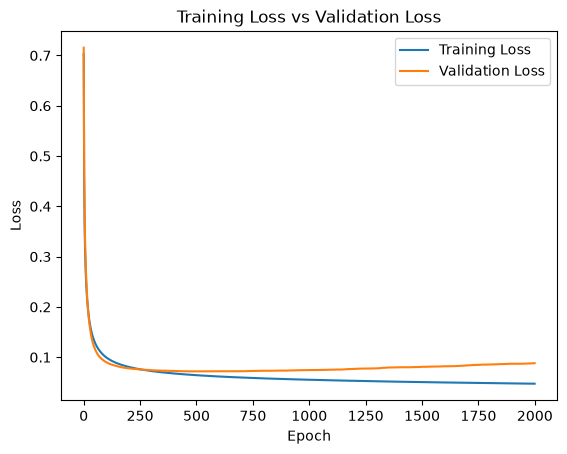

Training Accuracy: 0.986
Validation Accuracy: 0.967
Validation Precision: 0.97
Best epoch: 510, Best validation loss: 0.07180124521255493


In [200]:
loss_list = []
val_loss_list = []
training_accuracy_list = []
val_accuracy_list =[] # Unused - Keeping as may plot

best_val_loss = float('inf')
best_weights = None
best_epoch = None

nums_epoch = 2000 # Epoch is one complete pass through the training set

merged_training = TensorDataset(x_train, y_train)
train_loader = DataLoader(merged_training, batch_size=32, shuffle=True)

for epoch in range(nums_epoch):

    for x_batch, y_batch in train_loader:

        prediction = model(x_batch) # Takes x training data, produces new y_hat with current parameters
        loss = loss_function(prediction, y_batch) # Cost/Loss function calculation

        # Gradient Descent
        optimizer.zero_grad() # Clear current gradient information
        loss.backward() # Backprop - calculate partial derivatives based on current loss with respect to each contributing parameter
        optimizer.step() # Calculate the new weights based on step/learning rate

    with (torch.no_grad()):

        # Training loss for the completed epoch
        train_prediction = model(x_train)
        train_loss = loss_function(train_prediction, y_train)
        loss_list.append(train_loss.item())

        # Training accuracy for the completed epoch
        train_class = (train_prediction >= 0.5).float() # Threshold with boolean output
        training_correct = (train_class == y_train) # Boolean comparison
        training_accuracy = training_correct.sum().item() / len(training_correct)
        training_accuracy_list.append(training_accuracy)

        # Validation loss and accuracy for the completed epoch
        val_prediction = model(x_val)
        val_loss = loss_function(val_prediction, y_val)
        val_loss_list.append(val_loss.item())

        # Validation accuracy for the completed epoch
        val_class = (val_prediction >= 0.5).float() # Threshold with boolean output. Bool predictions
        val_correct = (val_class == y_val) # Boolean comparison with predictions vs actual
        val_accuracy = val_correct.sum().item() / len(val_correct)
        val_accuracy_list.append(val_accuracy)

        # Best Weights Tracking
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_weights = copy.deepcopy(model.state_dict())
            best_epoch = epoch

        # Print out of Epoch performance
        if epoch % 200 == 0:
            print('epoch = ', epoch,
                    ' training loss = ', train_loss.item(),
                    ' validation loss = ', val_loss.item(),
                    ' difference = ',
                  abs(train_loss.item()-val_loss.item())
            )

# Training Loss vs Validation Loss Plot
plt.plot(loss_list, label='Training Loss')
plt.plot(val_loss_list, label='Validation Loss')

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#-------------------------------------------
# Final Training / Validation Evaluation
# Using best validation weights
#-------------------------------------------

assert best_weights is not None
model.load_state_dict(best_weights)

model.eval()

with torch.no_grad():

    # Training predictions using best weights
    train_prediction = model(x_train)
    train_loss = loss_function(train_prediction, y_train)

    train_class = (train_prediction >= 0.5).float()
    training_correct = (train_class == y_train)
    training_accuracy = (
        training_correct.sum().item()
        / len(training_correct)
    )

    # Validation predictions using best weights
    val_prediction = model(x_val)
    val_loss = loss_function(val_prediction, y_val)

    val_class = (val_prediction >= 0.5).float()
    val_correct = (val_class == y_val)
    val_accuracy = (
        val_correct.sum().item()
        / len(val_correct)
    )

    # Validation Precision

    true_positive = (
        ((val_class == 1) & (y_val == 1))
        .sum()
        .item()
    )

    false_positive = (
        ((val_class == 1) & (y_val == 0))
        .sum()
        .item()
    )

    val_precision = (
        true_positive
        / (true_positive + false_positive)
    )

# Report Out

print(f"Training Accuracy: {round(training_accuracy, 3)}")
print(f"Validation Accuracy: {round(val_accuracy, 3)}")
print(f"Validation Precision: {round(val_precision, 3)}")

print(
    f"Best epoch: {best_epoch}, "
    f"Best validation loss: {best_val_loss}"
)


#### _**Confusion Matrix**_

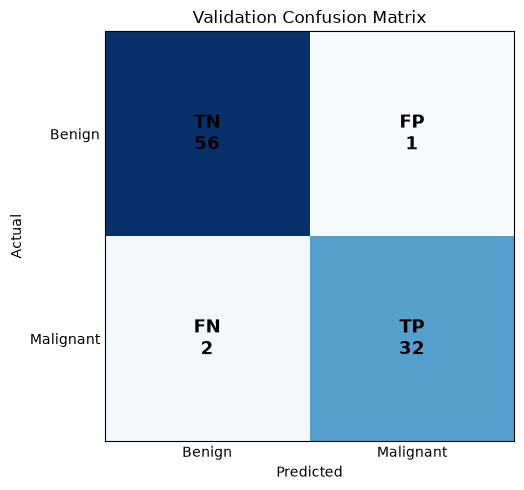

In [201]:
# Validation Confusion Matrix
true_positive = ((val_class == 1) & (y_val == 1)).sum().item()
true_negative = ((val_class == 0) & (y_val == 0)).sum().item()
false_positive = ((val_class == 1) & (y_val == 0)).sum().item()
false_negative = ((val_class == 0) & (y_val == 1)).sum().item()

confusion_matrix = [
    [true_negative, false_positive],
    [false_negative, true_positive]
]

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(confusion_matrix, cmap='Blues')

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Benign', 'Malignant'])
ax.set_yticklabels(['Benign', 'Malignant'])

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Validation Confusion Matrix')

# Cell labels
labels = [
    ['TN', 'FP'],
    ['FN', 'TP']
]

for row in range(2):
    for col in range(2):
        ax.text(
            col,
            row,
            f'{labels[row][col]}\n{confusion_matrix[row][col]}',
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold'
        )

# Remove little marks
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

### **Model Testing**

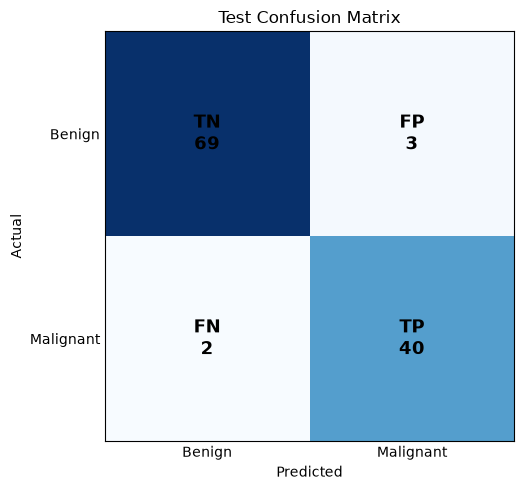

Test Loss =  0.09181472659111023
Test Accuracy: 0.956
Test Precision: 0.93


In [202]:
assert best_weights is not None
model.load_state_dict(best_weights)

model.eval()

with torch.no_grad():
    test_prediction = model(x_test)
    test_loss = loss_function(test_prediction, y_test)

    # Test accuracy
    test_class = (test_prediction >= 0.5).float() # Threshold with boolean output. Bool predictions
    test_correct = (test_class == y_test) # Boolean comparison with predictions vs actual
    test_accuracy = test_correct.sum().item() / len(test_correct)

# Test Confusion Matrix
t_true_positive = ((test_class == 1) & (y_test == 1)).sum().item()
t_true_negative = ((test_class == 0) & (y_test == 0)).sum().item()
t_false_positive = ((test_class == 1) & (y_test == 0)).sum().item()
t_false_negative = ((test_class == 0) & (y_test == 1)).sum().item()

t_confusion_matrix = [
    [t_true_negative, t_false_positive],
    [t_false_negative, t_true_positive]
]

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(t_confusion_matrix, cmap='Blues')

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(['Benign', 'Malignant'])
ax.set_yticklabels(['Benign', 'Malignant'])

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Test Confusion Matrix')

# Cell labels
labels = [
    ['TN', 'FP'],
    ['FN', 'TP']
]

for row in range(2):
    for col in range(2):
        ax.text(
            col,
            row,
            f'{labels[row][col]}\n{t_confusion_matrix[row][col]}',
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold'
        )

# Remove little marks
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

# Precision (How many positives were correct)
test_precision = t_true_positive / (t_true_positive+t_false_positive)

# Report Out
print("Test Loss = ", test_loss.item())
print(f"Test Accuracy: {round(test_accuracy, 3)}")
print(f"Test Precision: {round(test_precision, 3)}")

## **Results**

The test data was run with the best weights from the training/validation set loaded, resulting in an accuracy of 95.6% and precision of 93%, performing worse than the validation set by 1.1% and 4%, respectively. The test produced more false positive results but the same number of false negatives.

